In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

from src.query import (
    get_hourly_ridership,
    get_busiest_stations,
    get_ridership_by_hour,
    get_ridership_by_borough
)

In [2]:
stations = get_busiest_stations()
stations

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,station_complex,borough,total_ridership
0,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",Manhattan,168199492.0
1,"Grand Central-42 St (S,4,5,6,7)",Manhattan,115353598.0
2,"34 St-Herald Sq (B,D,F,M,N,Q,R,W)",Manhattan,97398981.0
3,"14 St-Union Sq (L,N,Q,R,W,4,5,6)",Manhattan,86563072.0
4,"Fulton St (A,C,J,Z,2,3,4,5)",Manhattan,70687785.0
5,"34 St-Penn Station (A,C,E)",Manhattan,68310781.0
6,"59 St-Columbus Circle (A,B,C,D,1)",Manhattan,63618073.0
7,"34 St-Penn Station (1,2,3)",Manhattan,62793978.0
8,"74-Broadway (7)/Jackson Hts-Roosevelt Av (E,F,...",Queens,58200035.0
9,Flushing-Main St (7),Queens,57023934.0


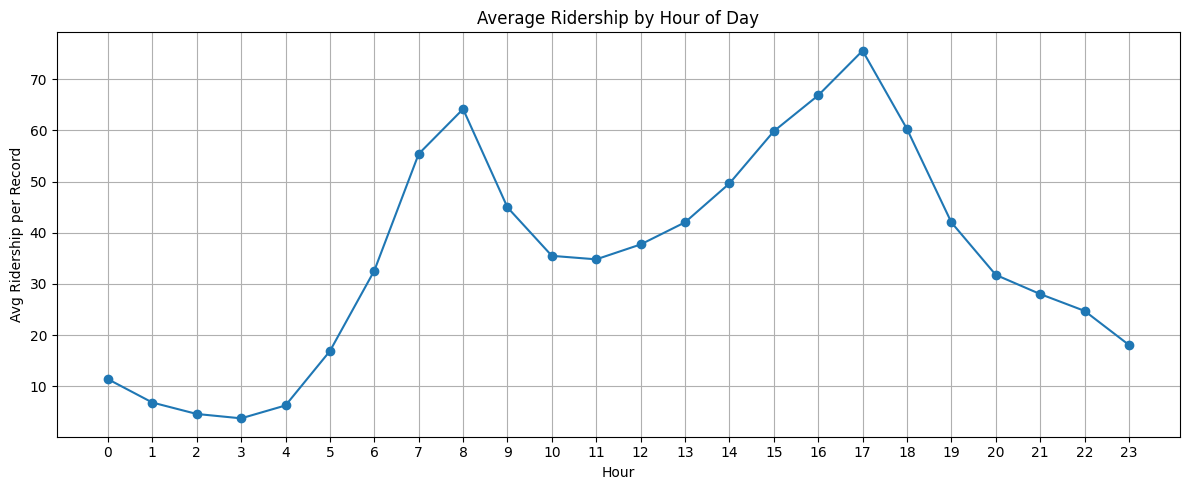

In [3]:
hourly = get_ridership_by_hour()

plt.figure(figsize=(12, 5))
plt.plot(hourly['hour_of_day'], hourly['avg_ridership'], marker='o')
plt.title('Average Ridership by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Ridership per Record')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

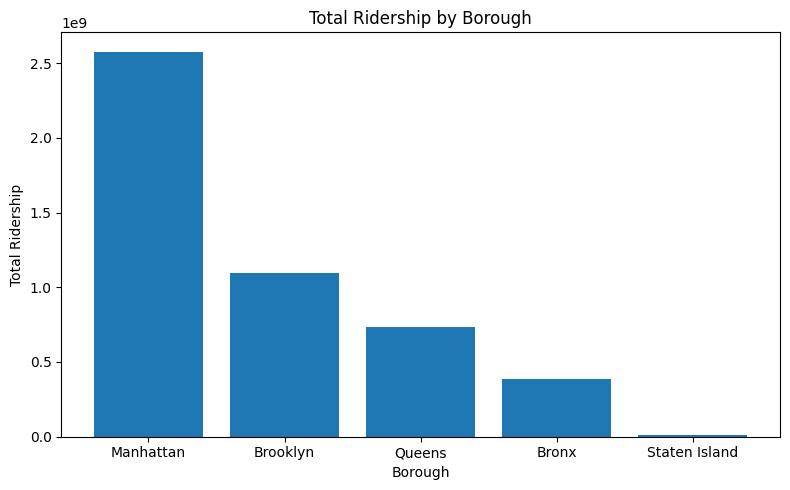

In [4]:
borough = get_ridership_by_borough()

plt.figure(figsize=(8, 5))
plt.bar(borough['borough'], borough['total_ridership'])
plt.title('Total Ridership by Borough')
plt.xlabel('Borough')
plt.ylabel('Total Ridership')
plt.tight_layout()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

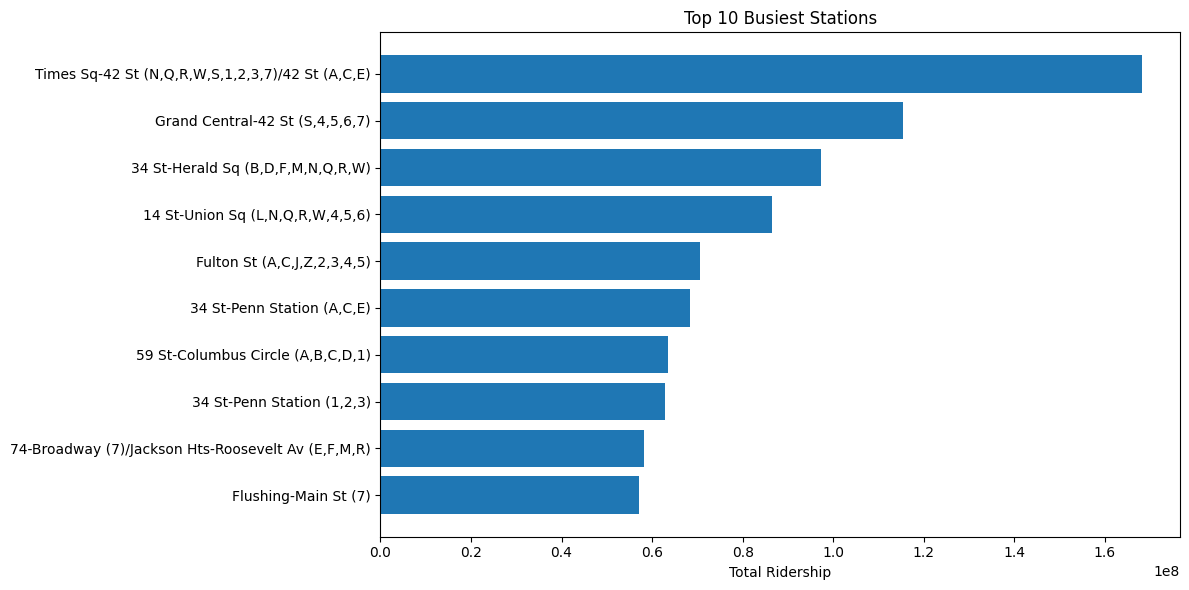

In [5]:
stations = get_busiest_stations(limit=10)

plt.figure(figsize=(12, 6))
plt.barh(stations['station_complex'], stations['total_ridership'])
plt.title('Top 10 Busiest Stations')
plt.xlabel('Total Ridership')
plt.gca().invert_yaxis()  # busiest at top
plt.tight_layout()
plt.show()

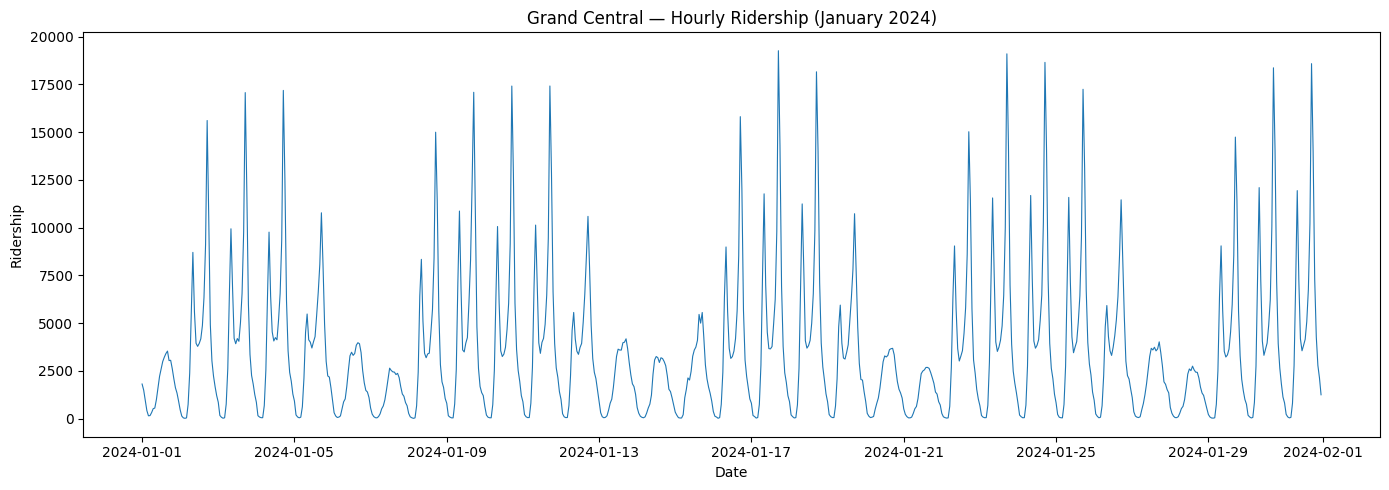

In [6]:
gc = get_hourly_ridership(
    station="Grand Central-42 St (S,4,5,6,7)",
    start="2024-01-01",
    end="2024-02-01"
)

plt.figure(figsize=(14, 5))
plt.plot(gc['transit_timestamp'], gc['ridership'], linewidth=0.8)
plt.title('Grand Central — Hourly Ridership (January 2024)')
plt.xlabel('Date')
plt.ylabel('Ridership')
plt.tight_layout()
plt.show()

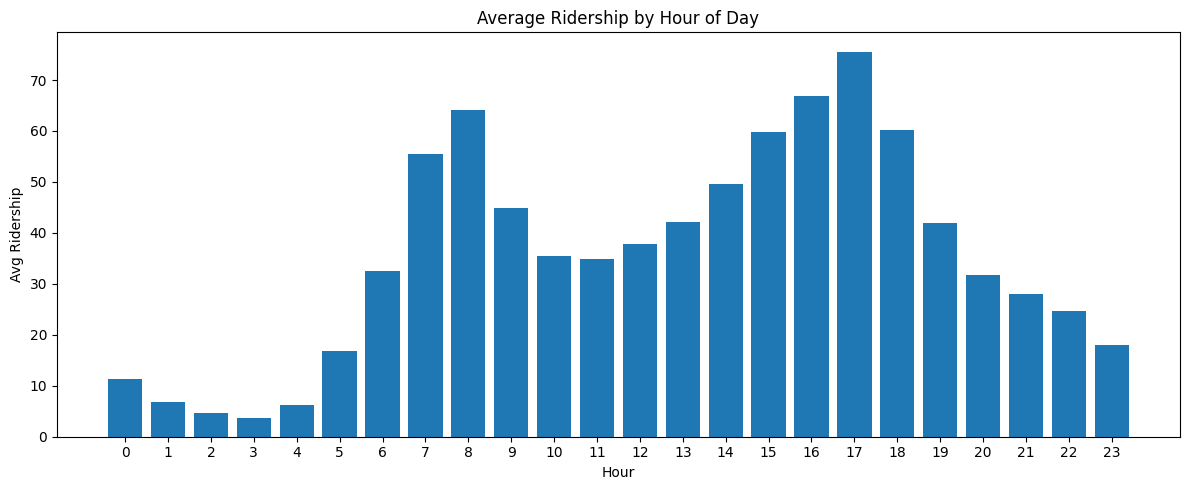

In [7]:
hourly = get_ridership_by_hour()

# We'll add day of week breakdown to query.py soon, but for now:
plt.figure(figsize=(12, 5))
plt.bar(hourly['hour_of_day'], hourly['avg_ridership'])
plt.title('Average Ridership by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Ridership')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

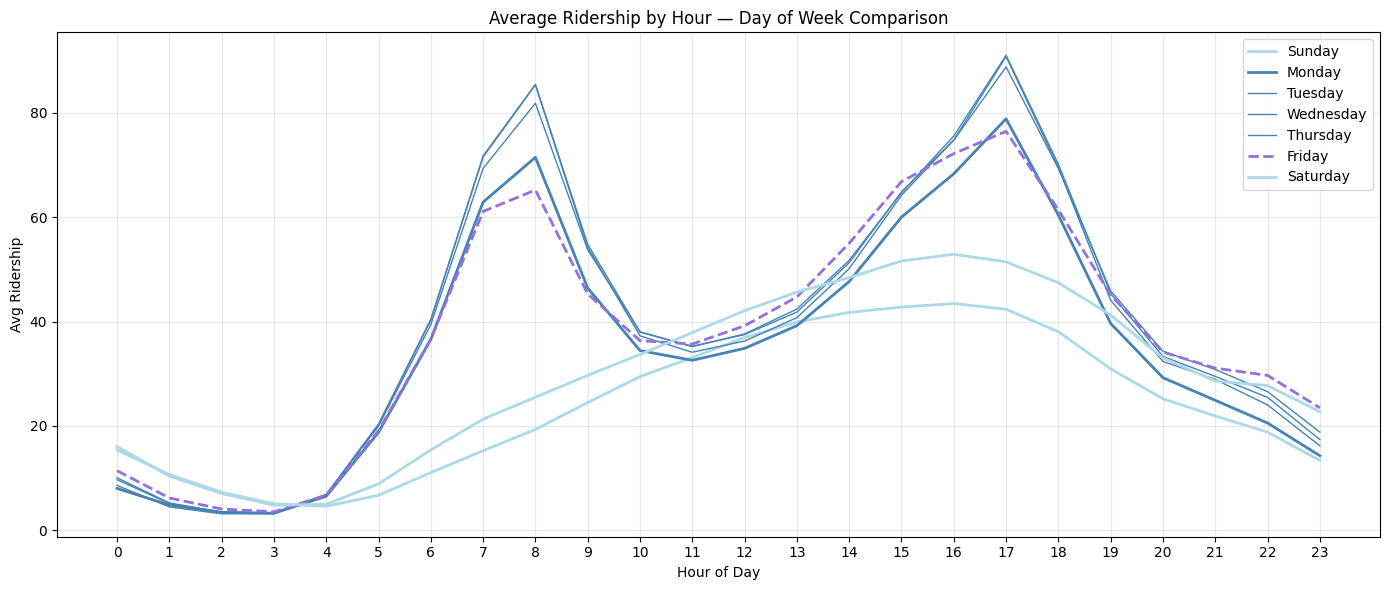

In [8]:
from src.query import get_ridership_by_day_of_week

dow = get_ridership_by_day_of_week()

days = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
colors = ['lightblue', 'steelblue', 'steelblue', 'steelblue', 'steelblue', 'mediumpurple', 'lightblue']

plt.figure(figsize=(14, 6))
for i, day in enumerate(days):
    day_data = dow[dow['day_name'] == day]
    plt.plot(day_data['hour_of_day'], day_data['avg_ridership'], 
             label=day, color=colors[i], 
             linewidth=2 if day in ['Monday','Friday', 'Saturday', 'Sunday'] else 1,
             linestyle='--' if day == 'Friday' else '-')

plt.title('Average Ridership by Hour — Day of Week Comparison')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Ridership')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Day of Week Patterns

- Clear AM/PM commute peaks on Tue-Thu
- Monday and Friday show reduced ridership — likely driven by WFH patterns
- Friday evening peak comparable to Mon-Thu morning peak
- Feature engineering implication: day of week should be one-hot encoded 
  or grouped (core weekday / shoulder day / weekend) rather than treated as ordinal

In [9]:
from src.query import get_hourly_ridership
from src.features import add_time_features

df = get_hourly_ridership(
    station="Grand Central-42 St (S,4,5,6,7)",
    start="2024-01-01",
    end="2024-02-01"
)
df = add_time_features(df)
df.head()

,transit_timestamp,station_complex,ridership,hour,day_of_week,month,week_of_year,is_weekend,is_shoulder_day,day_mon,day_tue,day_wed,day_thu,day_fri,day_sat,day_sun,hour_sin,hour_cos,month_sin,month_cos
0,2024-01-01 00:00:00,"Grand Central-42 St (S,4,5,6,7)",1815.0,0,0,1,1,0,1,1,0,0,0,0,0,0,0.000000,1.000000,0.5,0.866025
1,2024-01-01 01:00:00,"Grand Central-42 St (S,4,5,6,7)",1495.0,1,0,1,1,0,1,1,0,0,0,0,0,0,0.258819,0.965926,0.5,0.866025
2,2024-01-01 02:00:00,"Grand Central-42 St (S,4,5,6,7)",962.0,2,0,1,1,0,1,1,0,0,0,0,0,0,0.500000,0.866025,0.5,0.866025
3,2024-01-01 03:00:00,"Grand Central-42 St (S,4,5,6,7)",425.0,3,0,1,1,0,1,1,0,0,0,0,0,0,0.707107,0.707107,0.5,0.866025
4,2024-01-01 04:00:00,"Grand Central-42 St (S,4,5,6,7)",153.0,4,0,1,1,0,1,1,0,0,0,0,0,0,0.866025,0.500000,0.5,0.866025


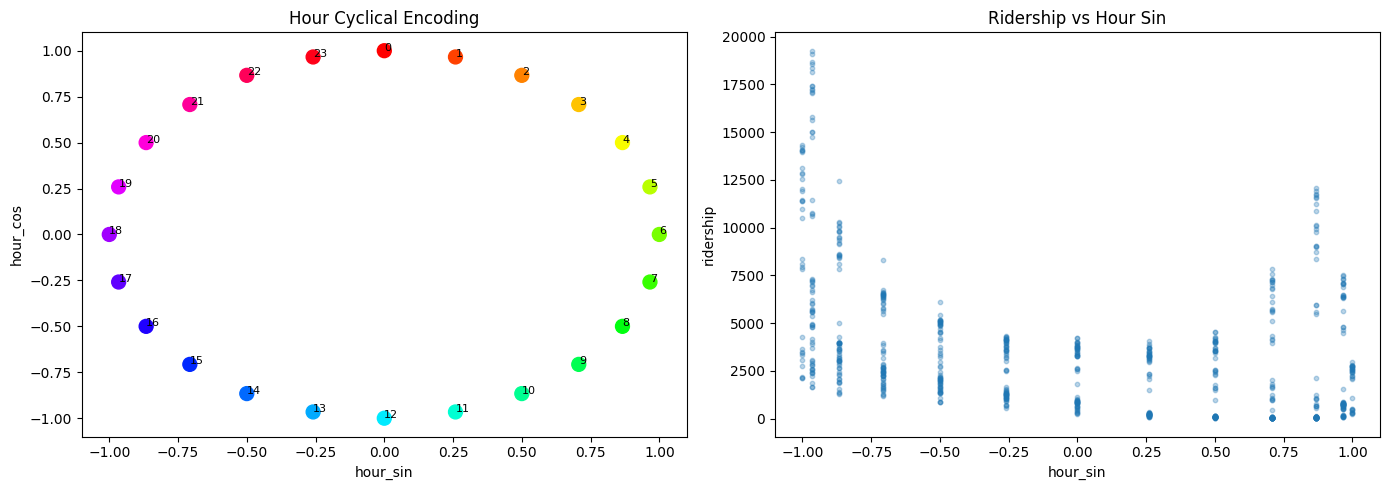

In [10]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hour encoding
hours = range(24)
hour_sin = [np.sin(2 * np.pi * h / 24) for h in hours]
hour_cos = [np.cos(2 * np.pi * h / 24) for h in hours]

axes[0].scatter(hour_sin, hour_cos, c=hours, cmap='hsv', s=100)
for h in hours:
    axes[0].annotate(str(h), (hour_sin[h], hour_cos[h]), fontsize=8)
axes[0].set_title('Hour Cyclical Encoding')
axes[0].set_xlabel('hour_sin')
axes[0].set_ylabel('hour_cos')

# Ridership by hour_sin — does the model see a clean signal?
axes[1].scatter(df['hour_sin'], df['ridership'], alpha=0.3, s=10)
axes[1].set_title('Ridership vs Hour Sin')
axes[1].set_xlabel('hour_sin')
axes[1].set_ylabel('ridership')

plt.tight_layout()
plt.show()

C:\Users\rayz2\AppData\Local\Temp\ipykernel_5792\3572228733.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_day, labels=day_names)


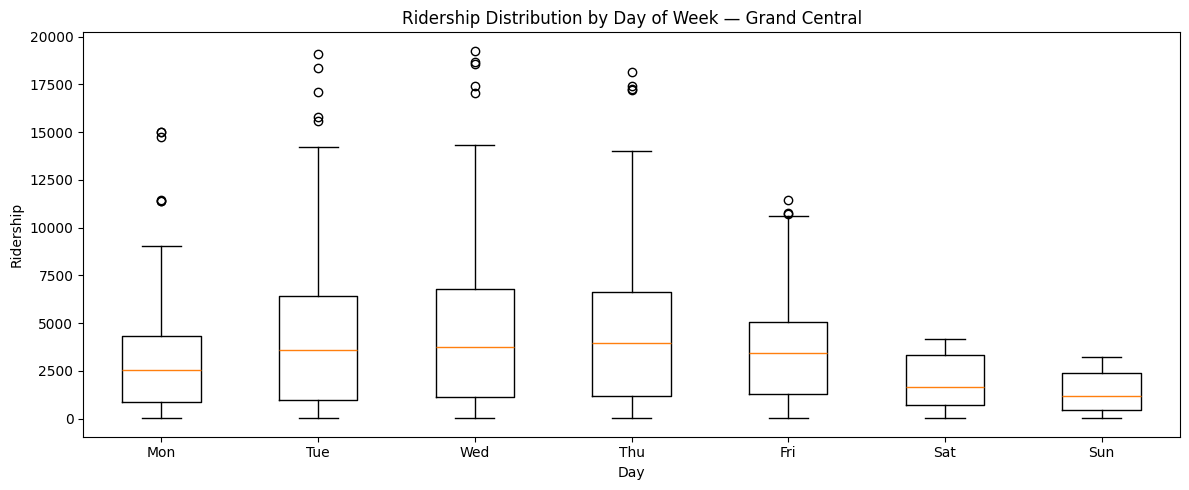

In [11]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(12, 5))
data_by_day = [df[df['day_of_week'] == i]['ridership'].values for i in range(7)]
ax.boxplot(data_by_day, labels=day_names)
ax.set_title('Ridership Distribution by Day of Week — Grand Central')
ax.set_xlabel('Day')
ax.set_ylabel('Ridership')
plt.tight_layout()
plt.show()

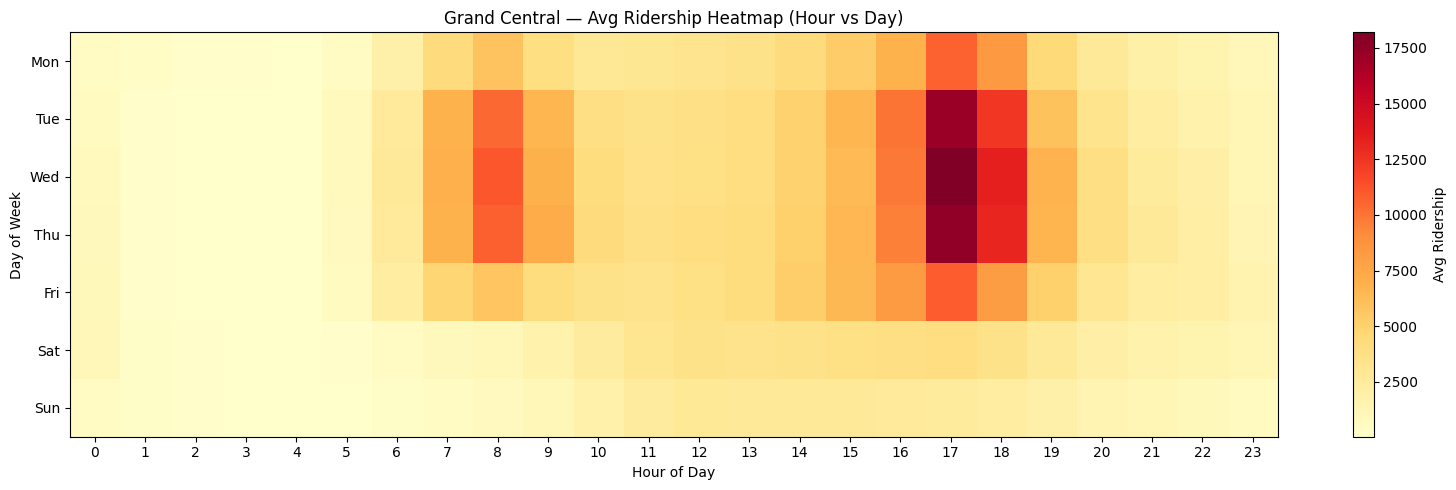

In [12]:
pivot = df.groupby(['day_of_week', 'hour'])['ridership'].mean().unstack()
pivot.index = day_names

plt.figure(figsize=(16, 5))
plt.imshow(pivot, aspect='auto', cmap='YlOrRd')
plt.colorbar(label='Avg Ridership')
plt.title('Grand Central — Avg Ridership Heatmap (Hour vs Day)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.xticks(range(24))
plt.yticks(range(7), day_names)
plt.tight_layout()
plt.show()

## Congestion Heatmap — Grand Central

Ridership is heavily concentrated on Tuesday-Thursday during morning (8am) 
and evening (5-6pm) rush hours. Weekend ridership is significantly lower 
and more evenly distributed across the day, consistent with Grand Central's 
role as a commuter hub serving Metro-North passengers.

In [13]:
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from src.query import get_hourly_ridership
from src.features import add_time_features, add_lag_features, drop_nulls, add_congestion_label
from src.model import prepare_features, train, evaluate, FEATURE_COLS

# Reload data and retrain so model is available in notebook
df = get_hourly_ridership(
    station="Grand Central-42 St (S,4,5,6,7)",
    start="2024-01-01",
    end="2024-12-01"
)

df = add_time_features(df)
df = add_lag_features(df)
df = drop_nulls(df)
df = add_congestion_label(df, horizon=2)

split = int(len(df) * 0.8)
train_df = df.iloc[:split]
test_df = df.iloc[split:]

X_train, y_train = prepare_features(train_df)
X_test, y_test = prepare_features(test_df)

model = train(X_train, y_train)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

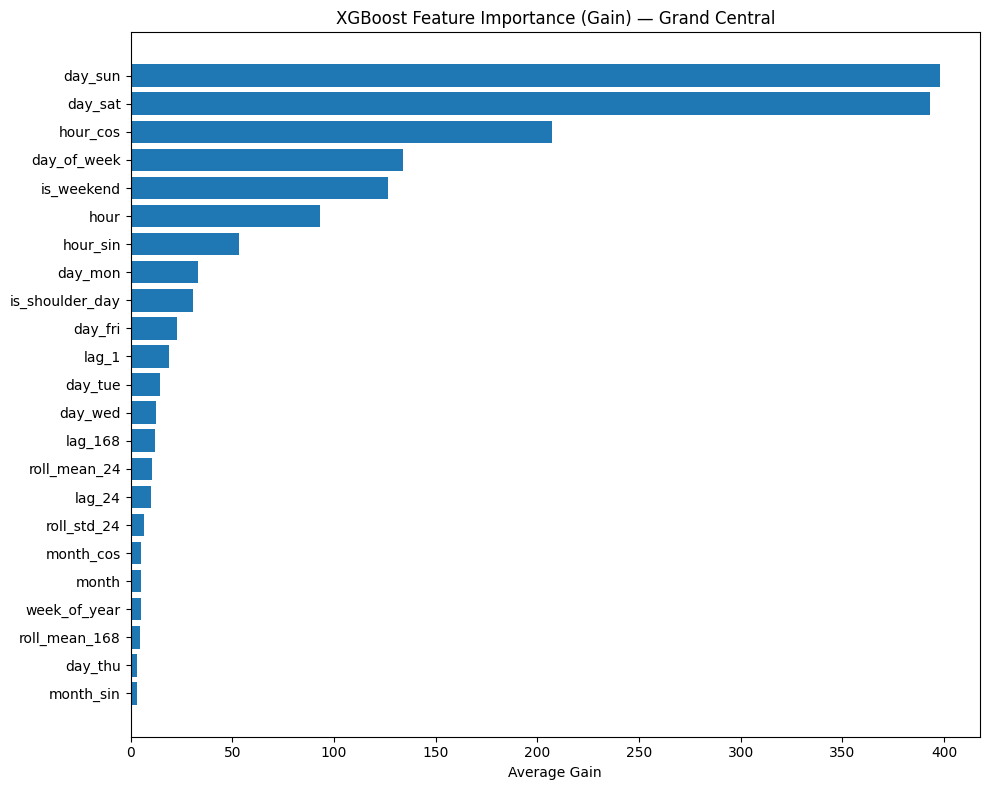

In [14]:
importance = model.get_booster().get_score(importance_type='gain')

# Sort and align with feature names
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.title('XGBoost Feature Importance (Gain) — Grand Central')
plt.xlabel('Average Gain')
plt.tight_layout()
plt.show()

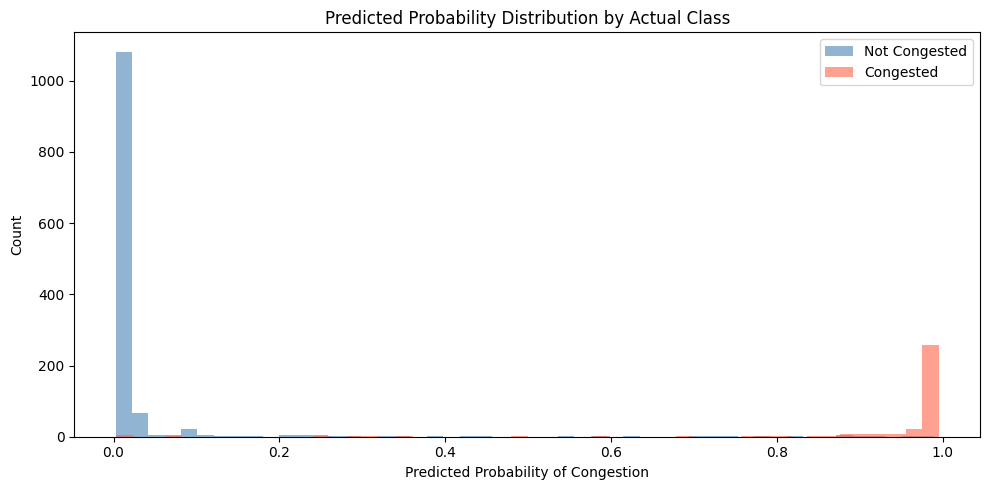

In [15]:
y_prob = model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 5))
plt.hist(y_prob[y_test == 0], bins=50, alpha=0.6, label='Not Congested', color='steelblue')
plt.hist(y_prob[y_test == 1], bins=50, alpha=0.6, label='Congested', color='tomato')
plt.title('Predicted Probability Distribution by Actual Class')
plt.xlabel('Predicted Probability of Congestion')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

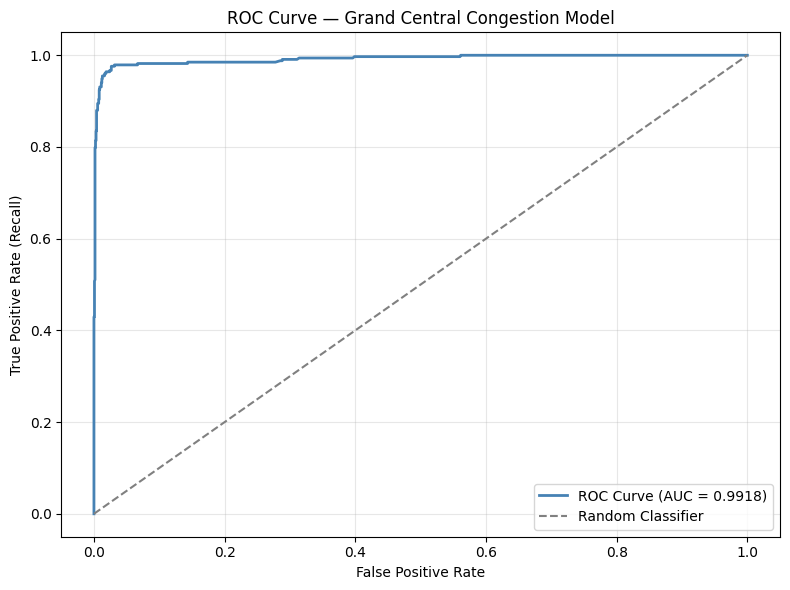

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.title('ROC Curve — Grand Central Congestion Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Importance Findings

Weekend indicators (day_sat, day_sun) dominate feature importance at Grand Central,
reflecting the station's commuter profile — weekday/weekend distinction is the 
strongest predictor of congestion.

hour_cos outperforms hour_sin, suggesting the model finds stronger signal in the 
midnight/noon axis than the 6am/6pm axis — off-peak hours are highly predictable.

Lag features contribute less than expected, implying that for regular commuter 
stations, temporal pattern alone is sufficient. Hypothesis: lag features will 
be more important at stations with less regular ridership patterns.

In [17]:
# Examine high confidence errors
test_df_copy = test_df.copy()
test_df_copy['predicted_prob'] = y_prob
test_df_copy['predicted'] = model.predict(X_test)
test_df_copy['actual'] = y_test.values

# False negatives where model was very confident
fn = test_df_copy[
    (test_df_copy['actual'] == 1) & 
    (test_df_copy['predicted_prob'] < 0.1)
]

print(f"High confidence false negatives: {len(fn)}")
print(fn[['transit_timestamp', 'ridership', 'hour', 'day_of_week', 'predicted_prob']].to_string())

High confidence false negatives: 7
       transit_timestamp  ridership  hour  day_of_week  predicted_prob
6611 2024-10-09 12:00:00     4301.0    12            2        0.080413
7022 2024-10-26 15:00:00     4935.0    15            5        0.009132
7023 2024-10-26 16:00:00     5870.0    16            5        0.007610
7024 2024-10-26 17:00:00     6046.0    17            5        0.004626
7209 2024-11-03 10:00:00     5724.0    10            6        0.003572
7694 2024-11-23 15:00:00     5160.0    15            5        0.009047
7786 2024-11-27 11:00:00     4261.0    11            2        0.020153
